<a href="https://colab.research.google.com/github/Slautin/camm_hackathon/blob/k4my4r/docs/day_2_10102025/Multiphase_disloc/CAMM_Hackathon_2_Boris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

October 10 2025

**Data provenance**

The dataset includes microstructural images collected from (i) a Ti–6Al–4V (Ti64) alloy sample, and (ii) Nb alloy. The images were acquired using optical/Laser microscopy



**What you’ll find here**

Raw metallographic/SEM images of alloy microstructures.

Baseline segmentation examples (e.g., k-means, thresholding) to illustrate challenges such as streak artifacts or misclassification.

**What you will do**

**Apply segmentation methods**  and record your observations.

**Compare techniques** and comment on their strengths and limitations.

**Visualize results** by overlaying predicted features or segmentation masks onto the original images.

# Importing data

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from PIL import Image
from sklearn.cluster import KMeans


import math
import numpy as np
from typing import Tuple, Optional, List

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from skimage import io, img_as_float
from skimage.util import view_as_windows
from tqdm import tqdm

## Two Sets of Images

*   Ti64
*   Nb Alloy



In [2]:
!gdown --fuzzy https://drive.google.com/file/d/1cS4aWLKAhwiXSHz23Yb8FEvyBFOO_U4C/view?usp=sharing
!gdown --fuzzy https://drive.google.com/file/d/1H4GwZYJyhDVoFPfA1_cT_8xQNvcAmuk1/view?usp=sharing



Downloading...
From: https://drive.google.com/uc?id=1cS4aWLKAhwiXSHz23Yb8FEvyBFOO_U4C
To: /content/Ti64.png
100% 997k/997k [00:00<00:00, 168MB/s]
Downloading...
From: https://drive.google.com/uc?id=1H4GwZYJyhDVoFPfA1_cT_8xQNvcAmuk1
To: /content/MultiPhase_w_Dislocations.tif
100% 1.88M/1.88M [00:00<00:00, 144MB/s]


# 1.Ti64

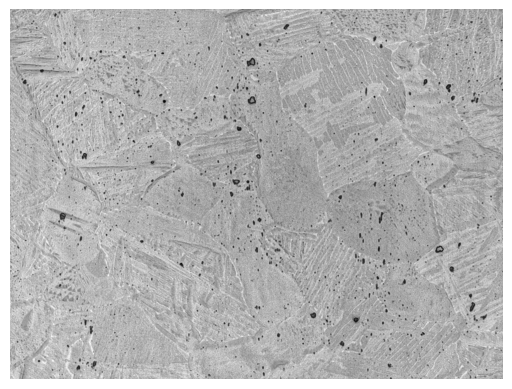

In [3]:
img1 = mpimg.imread("Ti64.png")
plt.imshow(img1)
plt.axis("off")
plt.show()


**What you see in the image**

The grayscale image above is a microscopy snapshot of Ti–6Al–4V (Ti64), a widely used aerospace alloy. Its internal structure has two major building blocks:

1.   α phase (alpha, light regions): Appears as the lighter gray regions. The α phase is stable at room temperature and gives the alloy strength.
2.   β phase (beta, darker regions): Seen as the darker intergranular regions. The β phase provides ductility (ability to bend/stretch).
3.   The small black spots visible across the sample are not another phase but likely surface dirt or minor preparation artifacts, not intrinsic features of the material.

**Why this matters**


Being able to classify which pixel belongs to α or β is the first step that lays the foundation for all subsequent characterization.

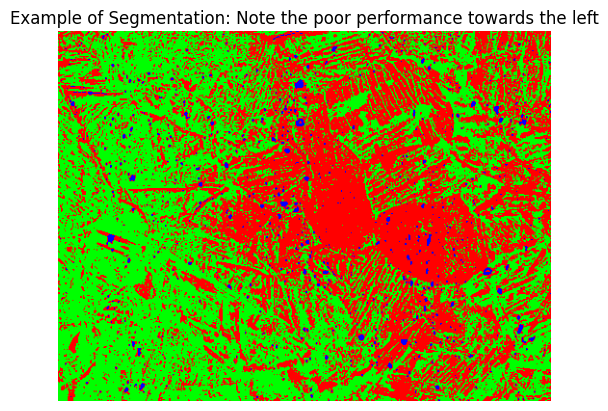

## Your Turn

Idea: apply **VAE** to encode data in low dimansional space and then cluster in the latent space by **kmeans**

In [4]:
#@title auxilary functions
from skimage.util import view_as_windows
import numpy as np

def crop_image(img: np.ndarray, N: int):
    """
    Crops an image into overlapping N×N patches (stride=1)
    and returns both the patches and their center coordinates.
    """
    if img.ndim == 2:
        H, W = img.shape
        C = None
    else:
        H, W, C = img.shape

    n_y = H - N + 1
    n_x = W - N + 1
    if n_y <= 0 or n_x <= 0:
        raise ValueError("Patch size N is too large for the input image.")

    if C is None:
        patches = view_as_windows(img, (N, N), step=1)
        patches = patches.reshape(-1, N, N)
    else:
        patches = view_as_windows(img, (N, N, C), step=1)
        patches = patches.reshape(-1, N, N, C)

    # ✅ Fixed center computation
    y_centers = np.arange(N//2, H - N//2 + 1)
    x_centers = np.arange(N//2, W - N//2 + 1)
    yy, xx = np.meshgrid(y_centers, x_centers, indexing='ij')
    centers = np.stack([yy.ravel(), xx.ravel()], axis=1)

    return patches, centers




def rgb_to_grayscale(img_rgb: np.ndarray) -> np.ndarray:
    """
    Convert an RGB image (H×W×3) to grayscale (H×W).

    Parameters
    ----------
    img_rgb : np.ndarray
        RGB image array with values in [0, 1] or [0, 255].

    Returns
    -------
    img_gray : np.ndarray
        Grayscale image (float32), same height and width.
    """
    if img_rgb.ndim != 3 or img_rgb.shape[2] != 3:
        raise ValueError("Input must be an RGB image (H×W×3).")

    # Ensure float for consistent computation
    img_rgb = img_rgb.astype(np.float32)

    # Normalize if values are 0–255
    if img_rgb.max() > 1.0:
        img_rgb = img_rgb / 255.0

    # Standard luminance-preserving conversion
    img_gray = 0.2989 * img_rgb[..., 0] + 0.5870 * img_rgb[..., 1] + 0.1140 * img_rgb[..., 2]
    return img_gray.astype(np.float32)



In [5]:
#@title vae model

class ConvVAE(nn.Module):
    def __init__(self, N: int, latent_dim: int = 8):
        super().__init__()
        self.N = N
        # Encoder: (B,1,N,N) -> (B, C, H', W') -> flatten -> mu, logvar
        self.enc = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),  # N -> N/2
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), # N/2 -> N/4
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),# N/4 -> N/8
            nn.ReLU(inplace=True),
        )
        # compute conv output size
        h = w = N
        for _ in range(3):  # three stride-2 downsamples
            h = math.ceil(h/2)
            w = math.ceil(w/2)
        self.enc_out_hw = (h, w)
        enc_flat_dim = 128 * h * w

        self.fc_mu = nn.Linear(enc_flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(enc_flat_dim, latent_dim)

        # Decoder
        self.fc_dec = nn.Linear(latent_dim, enc_flat_dim)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),  # N/8 -> N/4
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),   # N/4 -> N/2
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),   # N/2 -> N
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 1, 3, padding=1),
            nn.Sigmoid(),  # output in [0,1]
        )

    def encode(self, x):
        h = self.enc(x)
        h = h.view(h.size(0), -1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_dec(z)
        h = h.view(h.size(0), 128, *self.enc_out_hw)
        x_hat = self.dec(h)
        return x_hat

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar


# ----------------------------
# Loss
# ----------------------------
def vae_loss(x, x_hat, mu, logvar, beta=1.0, recon_loss="mse"):
    if recon_loss == "bce":
        recon = F.binary_cross_entropy(x_hat, x, reduction="sum")
    else:
        recon = F.mse_loss(x_hat, x, reduction="sum")
    # KL divergence (per sample)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta * kl, recon, kl


# ----------------------------
# Training
# ----------------------------
def train_vae(
    model: nn.Module,
    train_loader: DataLoader,
    epochs: int = 10,
    lr: float = 1e-3,
    beta: float = 1.0,
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for ep in range(1, epochs+1):
        total, recon_total, kl_total = 0.0, 0.0, 0.0
        for x in tqdm(train_loader, desc=f"Epoch {ep}/{epochs}", leave=False):
            x = x.to(device)
            x_hat, mu, logvar = model(x)
            loss, recon, kl = vae_loss(x, x_hat, mu, logvar, beta=beta, recon_loss="mse")
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item()
            recon_total += recon.item()
            kl_total += kl.item()
        n = len(train_loader.dataset)
        print(f"[{ep:03d}] loss={total/n:.6f} recon={recon_total/n:.6f} kl={kl_total/n:.6f}")
    return model


# ----------------------------
# Embedding & reconstruction over the full image
# ----------------------------
@torch.no_grad()
def encode_patches(model: nn.Module, patches: np.ndarray, batch_size: int = 256, device: str = None):
    """
    patches: (num_patches, 1, N, N)
    returns: mu (num_patches, latent_dim), logvar (num_patches, latent_dim)
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    ds = PatchDataset(patches, max_patches=None, shuffle=False)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)

    mus, logvars = [], []
    for x in tqdm(dl, desc="Encoding patches", leave=False):
        x = x.to(device)
        mu, logvar = model.encode(x)
        mus.append(mu.cpu())
        logvars.append(logvar.cpu())
    mu = torch.cat(mus, dim=0).numpy()
    logvar = torch.cat(logvars, dim=0).numpy()
    return mu, logvar


@torch.no_grad()
def reconstruct_image_from_patches(
    model: nn.Module,
    patches: np.ndarray,
    centers: np.ndarray,
    H: int,
    W: int,
    N: int
):
    """
    Decode each patch and overlap-average into an output image of size H×W.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    model.eval()

    dl = DataLoader(PatchDataset(patches, shuffle=False), batch_size=256, shuffle=False)
    recon = np.zeros((H, W), dtype=np.float32)
    weight = np.zeros((H, W), dtype=np.float32)

    half = N // 2
    idx = 0
    for x in tqdm(dl, desc="Decoding patches", leave=False):
        x = x.to(device)
        x_hat = model.decode(model.encode(x)[0]).cpu().numpy()  # (B,1,N,N)
        b = x_hat.shape[0]
        for i in range(b):
            cy, cx = centers[idx + i]
            y0, y1 = int(cy - half), int(cy - half + N)
            x0, x1 = int(cx - half), int(cx - half + N)
            patch = x_hat[i, 0]
            # clip for safety
            y0c, y1c = max(0, y0), min(H, y1)
            x0c, x1c = max(0, x0), min(W, x1)
            py0, py1 = y0c - y0, N - (y1 - y1c)
            px0, px1 = x0c - x0, N - (x1 - x1c)
            recon[y0c:y1c, x0c:x1c] += patch[py0:N - px1 + px0, px0:N - py1 + py0]
            weight[y0c:y1c, x0c:x1c] += 1.0
        idx += b

    weight[weight == 0] = 1.0
    return recon / weight


class PatchDataset(Dataset):
    def __init__(self, patches: np.ndarray, max_patches: Optional[int] = None, shuffle: bool = True):
        """
        patches: (num_patches, 1, N, N) float32 in [0,1]
        """
        self.patches = patches
        if shuffle:
            idx = np.random.permutation(len(patches))
            self.patches = self.patches[idx]
        if max_patches is not None:
            self.patches = self.patches[:max_patches]

    def __len__(self):
        return self.patches.shape[0]

    def __getitem__(self, i):
        x = self.patches[i]
        return torch.from_numpy(x)

In [6]:
#@title k_means functions
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.ndimage import gaussian_filter

def kmeans_segmentation_from_latent(mu: np.ndarray,
                                    centers: np.ndarray,
                                    img_shape: tuple,
                                    n_clusters: int = 3,
                                    smooth_sigma: float = 0.0):
    """
    Cluster latent vectors and map labels back to image coordinates.

    Parameters
    ----------
    mu : np.ndarray
        Latent vectors of shape (num_patches, latent_dim) from VAE encoder.
    centers : np.ndarray
        Patch center coordinates of shape (num_patches, 2): (y, x).
    img_shape : tuple
        Original image shape (H, W).
    n_clusters : int
        Number of clusters (phases) for KMeans.
    smooth_sigma : float
        Optional Gaussian smoothing sigma for final map.

    Returns
    -------
    label_map : np.ndarray
        2D segmentation map of shape (H, W) with cluster labels 0..(n_clusters-1).
    """

    H, W = img_shape
    print(f"Clustering {mu.shape[0]} latent vectors into {n_clusters} classes...")

    # --- Cluster in latent space ---
    km = KMeans(n_clusters=n_clusters, random_state=0, n_init='auto')
    labels = km.fit_predict(mu)

    # --- Create empty map and assign cluster labels to center coords ---
    label_map = np.zeros((H, W), dtype=np.int32)
    for (cy, cx), lbl in zip(centers, labels):
        cy, cx = int(round(cy)), int(round(cx))
        if 0 <= cy < H and 0 <= cx < W:
            label_map[cy, cx] = lbl

    # --- Optional smoothing / interpolation ---
    if smooth_sigma > 0:
        label_map = gaussian_filter(label_map.astype(float), sigma=smooth_sigma)
        label_map = np.rint(label_map).astype(int)

    return label_map, km


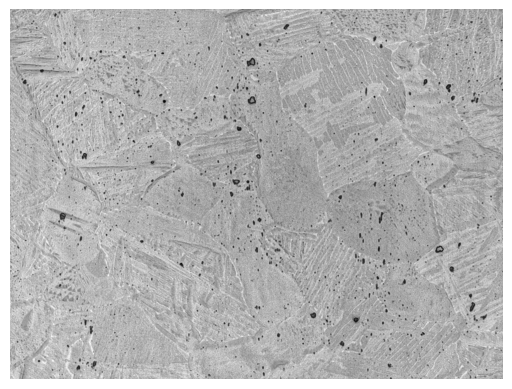

In [7]:
# image saved as img1
plt.imshow(img1)
plt.axis("off")
plt.show()

In [8]:
#1 to grayscale

N=8

img_gr = rgb_to_grayscale(img1)

patches, coords = crop_image(img_gr, N=N)

In [9]:
patches.shape, coords.shape

((773937, 8, 8), (773937, 2))

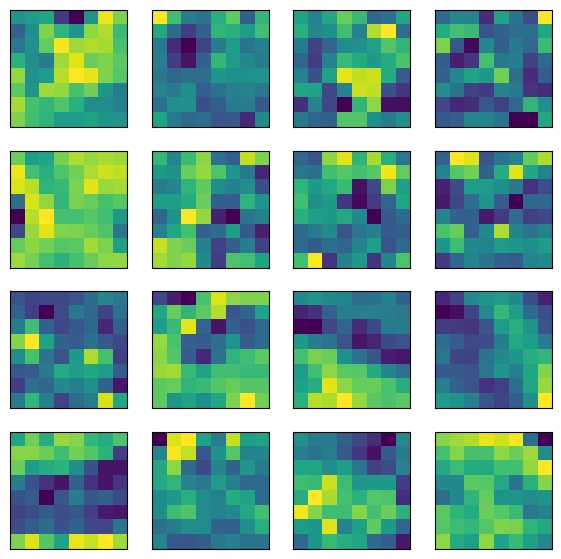

In [10]:
indd = np.random.randint(0,len(patches), 16)

fig, ax = plt.subplots(4, 4, figsize=(7,7))

for i, _ in enumerate(ax.flatten()):
  _.imshow(patches[indd[i]])
  _.set_xticks([])
  _.set_yticks([])

In [32]:
MAX_TRAIN_PATCHES = 150000

if len(patches) > MAX_TRAIN_PATCHES:
    idx = np.random.permutation(len(patches))[:MAX_TRAIN_PATCHES]
    train_patches = patches[idx]
else:
    train_patches = patches

# Ensure shape (num_patches, 1, N, N)
if train_patches.ndim == 3:
    # missing channel axis
    train_patches = train_patches[:, None, :, :]
elif train_patches.shape[1] != 1:
    # if second axis isn't the channel, reorder
    train_patches = np.moveaxis(train_patches, 0, 1)

print("train_patches shape:", train_patches.shape)


train_loader = DataLoader(PatchDataset(train_patches),
                          batch_size=256, shuffle=True, num_workers=4)

vae = ConvVAE(N=N, latent_dim=8)
vae = train_vae(vae, train_loader, epochs=20, lr=1e-4, beta=1)

print("Before encode:", patches.shape)

if patches.ndim == 3:
    # missing channel dimension
    patches = patches[:, None, :, :]
elif patches.shape[1] != 1:
    # channel dimension misplaced (e.g. (1, num_patches, N, N))
    patches = np.transpose(patches, (1, 0, 2, 3))

print("After fix:", patches.shape)

mu, logvar = encode_patches(vae, patches, batch_size=256)
print("Latent shape:", mu.shape)

train_patches shape: (150000, 1, 8, 8)


[001] loss=0.793445 recon=0.792340 kl=0.001106


[002] loss=0.503295 recon=0.503221 kl=0.000074


[003] loss=0.503203 recon=0.503161 kl=0.000042


[004] loss=0.503192 recon=0.503169 kl=0.000024


...

[017] loss=0.503026 recon=0.503022 kl=0.000004


[018] loss=0.503292 recon=0.503286 kl=0.000006


[019] loss=0.503128 recon=0.503124 kl=0.000004


[020] loss=0.503042 recon=0.503037 kl=0.000005
Before encode: (773937, 1, 8, 8)
After fix: (773937, 1, 8, 8)


Latent shape: (773937, 8)


In [35]:
res = kmeans_segmentation_from_latent(mu, coords, img_gr.shape, n_clusters=3)

Clustering 773937 latent vectors into 3 classes...


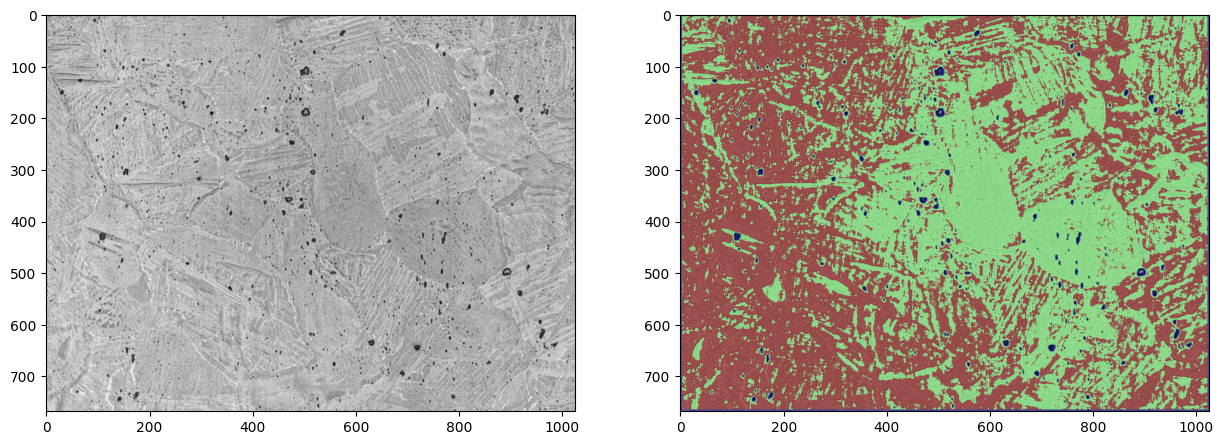

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].imshow(img_gr, cmap='gray')

ax[1].imshow(img_gr, cmap='gray')
ax[1].imshow(res[0], cmap='jet', alpha=0.6)

It seems to work, although I’m not sure if the improvement over the dummy K-means

# 2.Niobium alloy showing phases, dislocations, and cracks

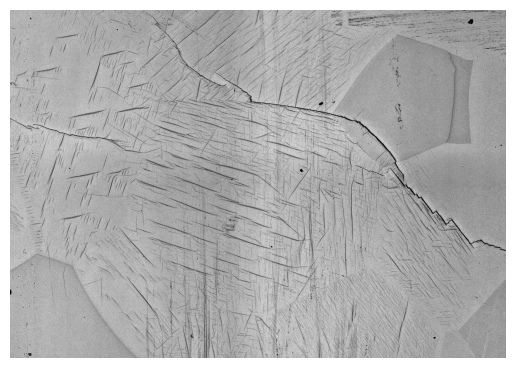

In [39]:
img2 = mpimg.imread("MultiPhase_w_Dislocations.tif")
plt.imshow(img2)
plt.axis("off")
plt.show()

This image shows a niobium (Nb) based alloy containing multiple phases and visible defects/dislocations.

**Phases:**

Nb alloys typically contain distinct crystalline regions (phases). Each phase has different contrast in the image because they scatter or absorb light/electrons differently.



*   **Phase A**: Different Grains
*   **Phase B (darker)**: Secondary precipitates or solute-rich regions showing as small cracks








**Artifacts**

* **Black spots:** Defects
* **Polishing artifact**: Visible on the top right of the image


**Deformation Features**

* **Cracking:** Two distinct cracks propagating through the microstructure.


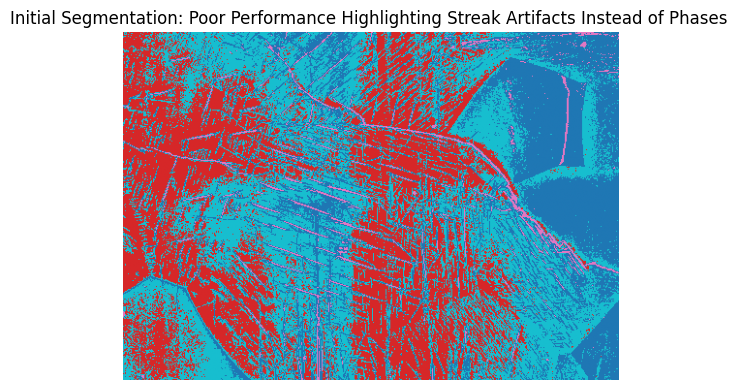

## Your turn

**The idea is to apply simple morphological filters to segment and separate additional phases and cracks.**

1) Enhance line-like structures by Fangi filter,
2) Shape filters: eccentricity - how elongated is structure, length along major dimension

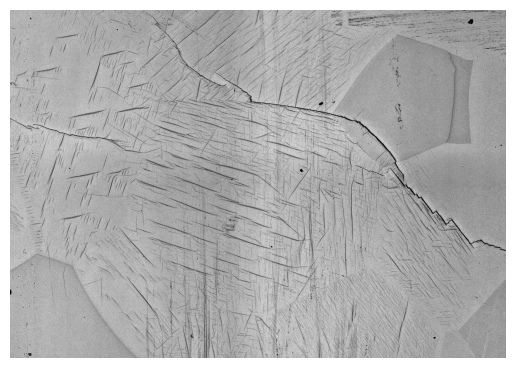

In [40]:
# image saved as img2
plt.imshow(img2)
plt.axis("off")
plt.show()

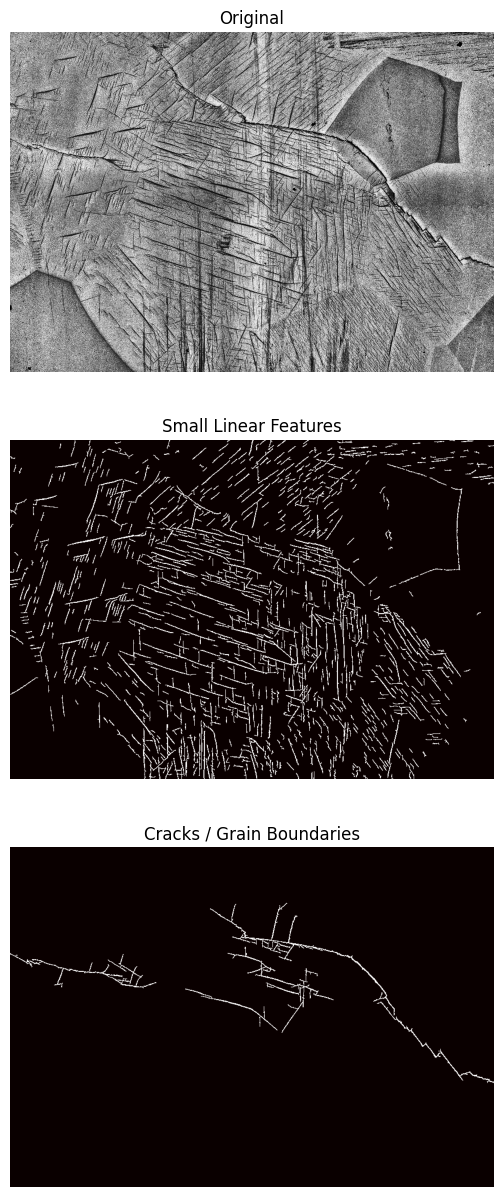

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters, morphology, measure, exposure
from skimage.filters import frangi,  sato

# --- Load & preprocess ---
img = img2
if img.ndim == 3:
    img = color.rgb2gray(img)
img = exposure.equalize_adapthist(img, clip_limit=0.02)

# --- Enhance line-like structures ---
line_enhanced = frangi(img)  # detects thin bright lines

# --- Threshold & clean ---
binary = line_enhanced > np.percentile(line_enhanced, 85)
binary = morphology.remove_small_objects(binary, min_size=15)
#binary = morphology.skeletonize(binary)

# --- Measure properties ---
props = measure.regionprops(measure.label(binary))
small_lines = np.zeros_like(binary)
cracks = np.zeros_like(binary)

props = measure.regionprops(measure.label(binary))
small_lines = np.zeros_like(binary)
cracks = np.zeros_like(binary)

for p in props:
    if p.major_axis_length < 180 and p.eccentricity > 0.8:
        small_lines[p.coords[:,0], p.coords[:,1]] = 1
    elif p.major_axis_length >= 200:
        cracks[p.coords[:,0], p.coords[:,1]] = 1

# --- Visualize ---
fig, axs = plt.subplots(3, 1, figsize=(15, 15))
axs[0].imshow(img, cmap='gray')
axs[0].set_title('Original')

axs[1].imshow(small_lines, cmap='hot')
axs[1].set_title('Small Linear Features')

axs[2].imshow(cracks, cmap='hot')
axs[2].set_title('Cracks / Grain Boundaries')
for ax in axs: ax.axis('off')
plt.show()


In [53]:
coord_small_lines = np.where(small_lines)
coord_cracks = np.where(cracks)

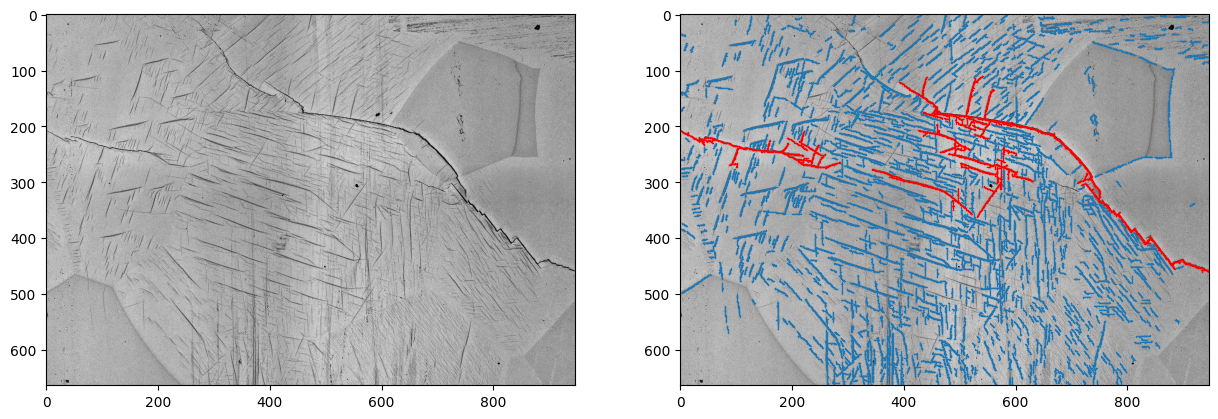

In [54]:
fig, ax = plt.subplots(1,2, figsize=(15,7))

ax[0].imshow(img2, cmap='gray')

ax[1].imshow(img2, cmap='gray')
ax[1].scatter(coord_small_lines[1],coord_small_lines[0], s=1, linewidth=0)
ax[1].scatter(coord_cracks[1],coord_cracks[0], s=1, linewidth=0, c='r')
